# Nonlinear Bayes classification
[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/rbig/blob/main/docs/notebooks/23_bayes_classifier.ipynb)

`RBIGBayesClassifier` is **nonlinear QDA**: it fits one RBIG density per
class and decides by `argmax_c [log p(x | c) + log π_c]`. Curved and
concentric class boundaries that break LDA (a linear boundary) come for
free, and the posteriors are calibrated because they come from actual
densities.

> **Colab / fresh environment?** Run the cell below to install `rbig`.
> Skip if already installed.

In [ ]:
!pip install "rbig[all] @ git+https://github.com/jejjohnson/rbig.git" -q

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from rbig import RBIGBayesClassifier

plt.style.use("seaborn-v0_8-paper")

/home/user/rbig/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data: two concentric rings

The classes share a center — a linear boundary is hopeless.

In [3]:
def two_rings(n_per, seed):
    rng = np.random.default_rng(seed)
    r = np.concatenate(
        [1.0 + 0.15 * rng.standard_normal(n_per), 2.4 + 0.15 * rng.standard_normal(n_per)]
    )
    th = rng.uniform(0, 2 * np.pi, 2 * n_per)
    X = np.column_stack([r * np.cos(th), r * np.sin(th)])
    return X, np.repeat([0, 1], n_per)


X, y = two_rings(500, 0)
X_te, y_te = two_rings(400, 1)

clf = RBIGBayesClassifier(n_layers=15, random_state=0).fit(X, y)
lda = LinearDiscriminantAnalysis().fit(X, y)

## Decision boundaries

The RBIG classifier's posterior wraps the inner ring; LDA can only draw
a straight line and lands near chance.

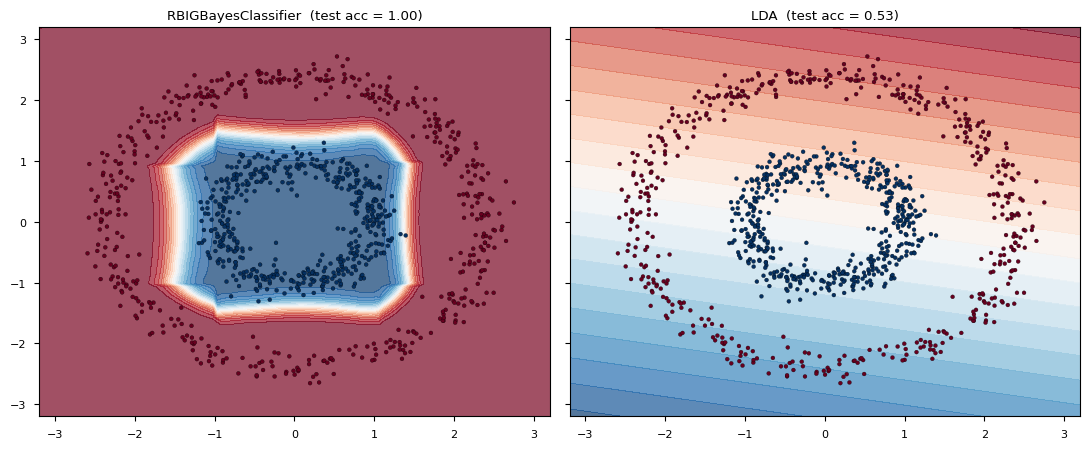

In [4]:
xx, yy = np.meshgrid(np.linspace(-3.2, 3.2, 130), np.linspace(-3.2, 3.2, 130))
grid = np.column_stack([xx.ravel(), yy.ravel()])
p_rbig = clf.predict_proba(grid)[:, 1].reshape(xx.shape)
p_lda = lda.predict_proba(grid)[:, 1].reshape(xx.shape)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11, 4.6), sharex=True, sharey=True)
for ax, p, title, acc in (
    (ax0, p_rbig, "RBIGBayesClassifier", clf.score(X_te, y_te)),
    (ax1, p_lda, "LDA", lda.score(X_te, y_te)),
):
    ax.contourf(xx, yy, p, levels=20, cmap="RdBu_r", alpha=0.7)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="RdBu_r", s=8, edgecolors="k", linewidths=0.2)
    ax.set_title(f"{title}  (test acc = {acc:.2f})")
plt.tight_layout()
plt.show()

In [5]:
print(f"RBIGBayesClassifier test accuracy: {clf.score(X_te, y_te):.3f}")
print(f"LDA test accuracy:                 {lda.score(X_te, y_te):.3f}")

RBIGBayesClassifier test accuracy: 0.998
LDA test accuracy:                 0.525


## Takeaways

- One flow per class turns the classifier's boundary into whatever
  shape the class densities imply — here, a ring. See the
  [benchmarks](../benchmarks.md) for held-out accuracy and Brier-score
  calibration vs LDA/QDA.
- The per-class flows use **tail-extended** marginals by default, so
  cross-class log-likelihoods stay finite and comparable in the tails
  near the boundary (with plain clipping marginals the comparison
  degenerates there).
- A low `max(predict_proba)` flags an **off-manifold** input — a free
  uncertainty signal for points in no class's high-density region.